# Toy example to check KL div loss

In [1]:
import numpy as np
import torch
from sklearn.cluster import KMeans
from torch.nn import KLDivLoss
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE
import wandb

from nnfabrik.utility.nn_helpers import set_random_seed


seed = 42
set_random_seed(seed)
torch.cuda.is_available()
cuda_number = 3
torch.cuda.set_device(f"cuda:{cuda_number}")
device = f'cuda:{cuda_number}'

In [2]:
cluster_number=2
dec_starting_epoch=30
alpha=1.0
kmeans_init=20
base_multiplier=4e3
exponent=1.2
data_spread = 5

In [3]:
from sklearn.datasets import make_blobs

# Generate a 5D dataset with two clusters
n_samples = 2000
n_features = 2
n_clusters = cluster_number
X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_clusters, random_state=42)
max_abs = 10  # Example threshold
X = X / np.max(np.abs(X), axis=0) 

# Print shape to verify
print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Feature matrix shape: (2000, 2)
Labels shape: (2000,)


In [106]:
def generate_functions(sample_size):
    functions = []

    # Cluster 1: Small variations (close to np.sum(X, axis=1))
    for i in range(sample_size):
        shift = np.random.uniform(0, 0.001)  # Tiny shifts
        functions.append(lambda X, s=shift: np.sum(X, axis=1) + s)

    # Cluster 2: Large shifts (well-separated from cluster 1)
    for i in range(int(sample_size/4)):
        shift = np.random.uniform(0, 0.005)  # Large shifts
        functions.append(lambda X, s=shift: 1.05* np.sum(X, axis=1) + s)

    return functions

# Apply functions
def apply_functions(X, sample_size):
    functions = generate_functions(sample_size)
    return np.column_stack([f(X) for f in functions])

f = apply_functions(X,2000)
print(f[0,:])

[0.24732862 0.2479048  0.24768608 ... 0.26362967 0.26420548 0.26133971]


Visualisation using kmeans

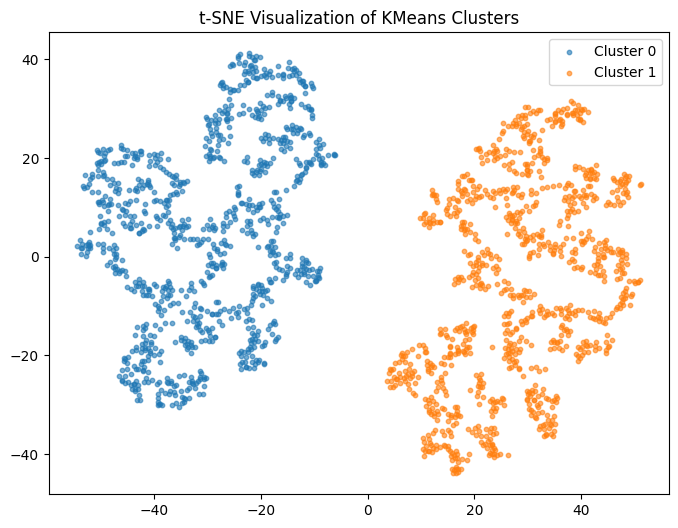

In [107]:
def kmeans_clustering(features, n_clusters=10):
    """Performs KMeans clustering on extracted features."""
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    predictions = kmeans.fit_predict(features)
    return kmeans, predictions

def visualize_tsne(features, predictions, n_clusters=10):
    """Performs t-SNE and visualizes clusters."""
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    reduced_features = tsne.fit_transform(features)

    plt.figure(figsize=(8, 6))
    for i in range(n_clusters):
        plt.scatter(
            reduced_features[predictions == i, 0], reduced_features[predictions == i, 1], 
            label=f'Cluster {i}', alpha=0.6, s=10,
        )
    
    plt.legend()
    plt.title("t-SNE Visualization of KMeans Clusters")
    plt.show()

def main(data, labels, n_clusters=10, device="cuda"):
    kmeans, predictions = kmeans_clustering(data, n_clusters)
    visualize_tsne(data, predictions, n_clusters)
    

main(X, y, n_clusters=2)

In [108]:
# create dataset
class ClusteredDataset(Dataset):
    def __init__(self, cluster_number=cluster_number, n_features=n_features, n_samples=n_samples, feature_size=1000, seed=42):
        np.random.seed(seed)

        #X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=cluster_number, random_state=seed)
        X = np.load("data_toy.npy")
        labels = np.load("toy_labels.npy")
        #labels = apply_functions(X, feature_size)

        # Print shape to verify
        print("Feature matrix shape:", X.shape)
        print("Labels shape:", labels.shape)

        self.data = torch.tensor(X, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Function to load the dataset
def load_dataset(batch_size=128, cluster_number=2,n_features=4,n_samples=2000, feature_size=2000):
    dataset = ClusteredDataset(cluster_number=cluster_number, n_features=n_features, n_samples=n_samples,feature_size=feature_size)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True), dataset

In [109]:
# simple linear model
import torch.nn as nn
class SimpleNN(nn.Module):
    def __init__(self, input_dim, output_dim=500):
        super(SimpleNN, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)  # Directly define the layer

    def forward(self, x):
        return self.linear(x)  # No need for Sequential

In [110]:
def update_alpha(resp, u, alpha, max_iter=10, tol=1e-4):
    'updates alpha when maximizing the log likelihood with newton method'
    for _ in range(max_iter):
        f_alpha = -torch.sum(
                resp * (1 + (torch.log(u) - u) + torch.special.digamma(alpha / 2) - torch.log(alpha/ 2))
            )
        f_prime_alpha = (1 / alpha) - (0.5 * torch.special.polygamma(1, alpha / 2))  # Trigamma function

        alpha_new = alpha - f_alpha / f_prime_alpha  # Newton-Raphson update

        # Ensure alpha stays in a valid range
        alpha_new = torch.clamp(alpha_new, min=0.01, max=100)

        if torch.abs(alpha_new - alpha) < tol:
            break

        alpha = alpha_new.detach()
    return alpha

In [111]:
def soft_assignments_mult(encoded_features, cluster_centers, sigma, alpha=1, p=1):
    sigma_inv = 1.0 / sigma  # (K, D)
    #print('sigma inv', sigma_inv)
    #print("NaNs in encoded_features:", torch.isnan(encoded_features).any())
    #print("NaNs in cluster_centers:", torch.isnan(cluster_centers).any())
    diff = encoded_features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)  # (N, K, D)
    #print(diff)
    norm_sigma = torch.sum(diff * sigma_inv*diff, dim=2)  # (N, K)
    #print('Norm sigma', norm_sigma)
    det = torch.sum(torch.log(sigma), dim=1)  # log(det) since sigma is diagonal

    # Log Gamma terms
    log_gamma_top = torch.lgamma((alpha + p) / 2)
    log_gamma_bottom = torch.lgamma(alpha / 2)

    # Log-density formula for multivariate Student-t
    log_pdf = (
        log_gamma_top - log_gamma_bottom
        - 0.5 * det
        - (p / 2) * torch.log(alpha * torch.pi)
        - ((alpha + p) / 2) * torch.log(1 + (norm_sigma / alpha))
    )

    #print('log pdf' , log_pdf)
    #print('exp(log) pdf', torch.exp(log_pdf))
    #log_assignments = log_pdf - torch.logsumexp(log_pdf, dim=1, keepdim=True)
    log_pdf_max = torch.max(log_pdf, dim=1, keepdim=True)[0]  # Get max per row
    log_assignments = log_pdf - log_pdf_max - torch.logsumexp(log_pdf - log_pdf_max, dim=1, keepdim=True)
    #print('log assignmnents ', log_assignments)

    return torch.exp(log_assignments)  # Convert log-assignments to probabilities

def target_distribution(batch: torch.Tensor, exponent=exponent) -> torch.Tensor:
    weight = (batch**exponent) / torch.sum(batch, 0)
    return (weight.t() / torch.sum(weight, 1)).t()

def EM_t_mult(features, resp, cluster_centers, sigma, alpha, d=1):
    sigma_inv = 1.0 / sigma  # (K,)
    diff = (features.T.unsqueeze(1) - cluster_centers.unsqueeze(0))
    norm_sigma = torch.sum((diff **2 * sigma_inv),2)  
    u = ((alpha + d)/(alpha +norm_sigma)).detach()  #ccalculate U shape(N,K)
    #print('u', u.shape)
    #print(resp.shape)
    
    ''' M step '''
    numerator = torch.matmul(features,resp*u).T.detach()
    #print(numerator.shape)
    denominator = torch.sum(resp*u, dim=0, keepdim=True).T.detach()
    #print(denominator.shape)
    cluster_centers = numerator/denominator

    weighted_sq_diff = resp.unsqueeze(2)* u.unsqueeze(2) * (diff ** 2)  # (N, K, D)
    numerator = weighted_sq_diff.sum(dim=0) #(K,D)
    denominator = torch.sum(resp, dim=0, keepdim=True)  # (K,)
    #print('sigma de', denominator.shape)
    sigma = (numerator / denominator.T).detach() 
    
    sigma = torch.clamp(sigma, min=1e-4, max=1e4)

    return cluster_centers, sigma

In [112]:
def EM_t_1D(features, resp, cluster_centers, taus, alpha, d=1):
    norm_squared = torch.sum(
    (features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)) ** 2, dim=2
    )  
    u = (alpha + d)/(alpha +norm_squared*(taus**(-1)))  #ccalculate U shape(N,K)
    print('u', u.shape)
    print(resp.shape)
    ''' M step '''
    numerator = torch.matmul(features,resp*u).T.detach()
    print(numerator.shape)
    denominator = torch.sum(resp*u, dim=0, keepdim=True).T.detach()
    print(denominator.shape)
    cluster_centers = numerator/denominator

    weighted_sums = torch.sum(resp* u * norm_squared, dim=0) 
    #print('WS', weighted_sums.shape)
    taus = (weighted_sums / torch.sum(resp, dim=0, keepdim=True)).detach()
    #print('Tau', taus.shape)
    return cluster_centers, taus


def soft_assignments_1D(encoded_features, cluster_centers, tau, alpha=1, p=1):
    norm_squared = torch.sum(
        (encoded_features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)) ** 2, 2
    )
    assignments = 1.0 / (1.0 + (norm_squared / (alpha * tau)))
    assignments = (assignments ** ((alpha + p) / 2))/(tau**1/2)
    #print('Assignments shape', assignments.shape)
    return assignments / torch.sum(assignments, dim=1, keepdim=True)

In [113]:
def trainer(model, dataloader, cluster_number=cluster_number, kmeans_init=10, 
            dec_starting_epoch=dec_starting_epoch,
            use_wandb = True,
            use_diag_cov=True,
            learn_alpha=True,
            log_likelihood_alpha=False,
            exponent=exponent, lr=0.008, epochs=100, device=device, alpha = 1.0):
    '''
    use_diag_conv: Bool that indicates wether to use a diagonal covariance matrix or just one value for each cluster
    '''
    p = model.linear.in_features
    cluster_centers = torch.nn.Parameter(
        torch.zeros(
            cluster_number,
            p,
            dtype=torch.float,
            device=device,
        ),
        requires_grad=True,
    )  
    if use_diag_cov:

        sigma = torch.nn.Parameter(
            torch.zeros(
                cluster_number,
                p,
                dtype=torch.float,
                device=device,
            ),
            requires_grad=True,
        )  
        #alpha = torch.nn.Parameter(torch.tensor(1.0, device=device, requires_grad=True))
        alpha = torch.tensor(alpha, device=device, requires_grad=False)
        optimizer = torch.optim.Adam(
            list(model.parameters())
            + [cluster_centers] +  [sigma],  # Combine model params and additional tensor
            lr=lr
            )
    else:
        alpha = torch.tensor(alpha, device=device, requires_grad=False)
        optimizer = torch.optim.AdamW(
            list(model.parameters())
            + [cluster_centers] ,  # Combine model params and additional tensor
            lr=lr,
            )
    kldiv_criterion = KLDivLoss(
        size_average=False
    )  # losses are summed for each minibatch
    criterion = nn.MSELoss()
    if use_wandb:
        wandb.init(
            project='Toy example',
            entity='ninasophie-nellen-g-ttingen-university',
            name='toy run higher dimensoinal epsilon 1, learned centers',
            config={
                "learning_rate": lr,
                "cur_epochs": epochs,
            },
        )
        wandb.run.log_code(".")
        # metrics represent any value I want to track, if they're hidden, they're not displayed on default cisualisation
        wandb.define_metric(name="Epoch", hidden=True)
        wandb.define_metric(name="Batch", hidden=True)

    model.to(device)
    model.train()

    prev_loss = float('inf')  # Initialize with a high value
    decreasing = True  # Track if loss was previously decreasing
    for epoch in range(epochs):

        epoch_loss = 0
        epoch_kldiv_loss = 0
        epoch_loss_main = 0
        '''
        if epoch >= 50:
            lr = 0.0005
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        '''
        if epoch == dec_starting_epoch:
            cluster_centers_list = []
            features = model.linear.weight.data.detach().cpu().numpy()
            #print(features.shape)
            kmeans = KMeans(
                n_clusters=cluster_number, n_init=kmeans_init, random_state=seed
            )
            with torch.no_grad():
                predicted = kmeans.fit_predict(features)

            cluster_centers.data = torch.tensor(
                kmeans.cluster_centers_, dtype=torch.float, device=device
            )
            print(cluster_centers)
            mixing_coefficient = torch.ones(cluster_number, device=device) / cluster_number 
            if use_diag_cov:
                for k in range(cluster_number):
                    cluster_points = torch.from_numpy(features[predicted == k]).to(device) 
                    if len(cluster_points) > 0:
                        sigma[k].data.copy_(torch.var(cluster_points, dim=0, unbiased=True) + 1e-6)

            else: 
                '''
                for k in range(cluster_number):
                    cluster_points = torch.from_numpy(features[predicted == k]).to(device)  
                    if len(cluster_points) > 0:
                        sigma[k].data.copy_(torch.var(cluster_points, dim=0, unbiased=True) + 1e-6)
                sigma = sigma.unsqueeze(0)'
                '''
                sigma=1
                p=1
            if learn_alpha:
                alpha.data = torch.tensor(1.0, dtype=torch.float, device=device)

            print('Sigma beginning', sigma)
            with torch.no_grad():
                cluster_centers_list.append(cluster_centers.cpu().detach().numpy())
            
            tsne = TSNE(n_components=2, learning_rate=features.shape[0]/12, perplexity=30, random_state=42)
            reduced_features = tsne.fit_transform(features)

            plt.figure(figsize=(8, 6))
            plt.scatter(
                reduced_features[:, 0], reduced_features[:, 1], alpha=0.6, s=10,)
            plt.title("t-SNE Visualization of KMeans Clusters")
            plt.show()

        for i, (inputs, labels) in enumerate(dataloader): 
            #if epoch < dec_starting_epoch:
            inputs = inputs.to(device)     
            labels = labels.to(device) 
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward() 
            if epoch >= dec_starting_epoch:
                features = model.linear.weight.T
                if use_diag_cov:
                    with torch.no_grad():
                        sigma.data.clamp_(min=1e-5)  # Ensure sigma is always positive
                        print('sigma', sigma)
                for name, param in model.named_parameters():
                    if param.grad is not None and torch.isnan(param.grad).any():
                        print(f"NaN in gradients of {name}")
                    if torch.isinf(param.grad).any():
                        print(f"🚨 Inf detected in gradient of {name}")

                if use_diag_cov:
                    q = soft_assignments_mult(features, cluster_centers, sigma, alpha,p)
                else:
                    q = soft_assignments_1D(features, cluster_centers, sigma, alpha,p)

                target = target_distribution(q, exponent)
                target = target.clamp(min=1e-10)
                #sigma = sigma.clamp(min=1e-10)
                q = q.clamp(min=1e-10)
                    
                kldiv_loss =  kldiv_criterion(q.log(), target)
                #print('KL loss', kldiv_loss)

                #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
                kldiv_loss.backward()

                if kldiv_loss > prev_loss and decreasing:
                    print(f"⚠️ Warning: Loss spiked at epoch {epoch}! Prev: {prev_loss:.4f}, Current: {kldiv_loss:.4f}")
                    for name, param in model.named_parameters():
                        if param.grad is not None:
                            print(f"Gradient norm for {name}: {param.grad.norm().item():.6f}")
                    print(f"Gradient norm for cluster_centers: {cluster_centers.grad.norm().item():.6f}")
                    print(f"Gradient norm for sigma: {sigma.grad.norm().item():.6f}") 
                decreasing = (kldiv_loss +1) < (prev_loss)  # Update trend tracker
                prev_loss = kldiv_loss  # Store last loss
                low_values_mask = (q < 1).all(dim=1)
                true_count = low_values_mask.sum()

                print('Q values where prob is not 1' , true_count) 
                for name, param in model.named_parameters():
                    if param.grad is not None and torch.isnan(param.grad).any():
                        print(f"NaN detected in gradients of {name}")
                    if torch.isinf(param.grad).any():
                        print(f"🚨 Inf detected in gradient of {name}")
                #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)

                epoch_kldiv_loss += kldiv_loss.detach()
                #print('KL loss', kldiv_loss)
                epoch_loss += kldiv_loss.detach()

                
                #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                #torch.nn.utils.clip_grad_norm_([cluster_centers, sigma], max_norm=5.0)
                #print('cluster centers', cluster_centers)
                with torch.no_grad():
                    cluster_centers_np = cluster_centers.cpu().detach().numpy()
                    cluster_centers_list.append(cluster_centers_np)
            optimizer.step()  
            optimizer.zero_grad()   
            #print(alpha)

        #print(f"Epoch {epoch}, loss: {loss}")
        if use_wandb:
            wandb_dict = {
                "Epoch Train loss": epoch_loss,
                "Epoch Train loss main": epoch_loss_main,
                "Epoch Train loss Kullback-Leibler-divergence": epoch_kldiv_loss,
            }
            wandb.log(wandb_dict)

    print(cluster_centers)
    print("Training Complete!")
    model.eval()
    features = model.linear.weight.data.detach()
    if use_diag_cov:
        q = soft_assignments_mult(features.T, cluster_centers, sigma, alpha,p)
    else:
        q = soft_assignments_1D(features.T, cluster_centers, sigma, alpha,p)
    features = (features).cpu().numpy()
    predictions = (q).max(1)[1].cpu().numpy()
    cluster_centers_np = np.array(cluster_centers_list)

    #print('features: ', features.shape)
    #print('predictions: ', predictions.shape)
    print('cluster centers ', cluster_centers_np.shape)
    #print('TAu', sigma)
    print('Alpha', alpha)
    return features, predictions, cluster_centers_np

Feature matrix shape: (8000, 30)
Labels shape: (8000, 2500)


/user/ninasophie.nellen/anaconda3/envs/my_env/lib/python3.12/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


Parameter containing:
tensor([[0.7813, 0.0939, 0.4025, 0.3579, 0.5071, 0.5064, 0.4665, 0.1978, 0.5019,
         0.3570, 0.4703, 0.0436, 0.2289, 0.5400, 0.5402, 0.5005, 0.6316, 0.9927,
         0.9087, 0.6148, 0.2783, 0.5100, 0.6024, 0.7675, 0.9407, 0.0754, 0.5489,
         1.0198, 0.9162, 0.4578],
        [0.7603, 0.1215, 0.3556, 0.5740, 0.4553, 0.4768, 0.5151, 0.2081, 0.6419,
         0.4013, 0.5424, 0.0743, 0.2204, 0.4852, 0.6054, 0.4927, 0.7042, 0.9974,
         0.9006, 0.7112, 0.4748, 0.4914, 0.5232, 0.6587, 0.9109, 0.1481, 0.6510,
         1.0478, 0.7973, 0.5227],
        [0.8557, 0.1733, 0.5893, 0.3488, 0.6073, 0.5781, 0.4927, 0.3208, 0.5241,
         0.4547, 0.4839, 0.0842, 0.3696, 0.6373, 0.5639, 0.5591, 0.6487, 0.9993,
         0.9542, 0.6106, 0.2793, 0.5832, 0.7133, 0.8646, 0.9677, 0.1108, 0.5532,
         0.9650, 0.9522, 0.4978]], device='cuda:3', requires_grad=True)
Sigma beginning 1


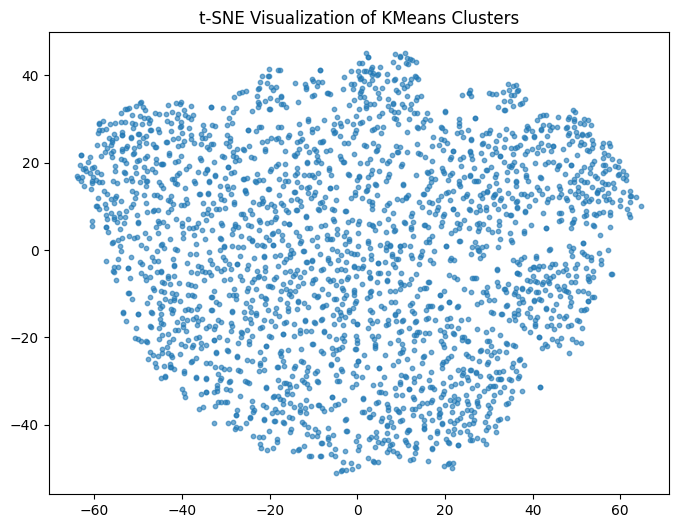

Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3')
Q values where prob is not 1 tensor(2500, device='cuda:3

In [154]:
dataloader, dataset = load_dataset(batch_size=256, n_features=30, n_samples=8000, feature_size=2000)
model = SimpleNN(input_dim=30, output_dim=2500)
cluster_number=3
features, predictions, cluster_centers_list = trainer(model, dataloader, dec_starting_epoch=30, 
                                                      cluster_number=cluster_number,
                                                      exponent=2, epochs=40, use_wandb=False, 
                                                      log_likelihood_alpha=False,
                                                      use_diag_cov=False, learn_alpha=False, alpha=1)

In [155]:
print(predictions)

[0 0 0 ... 0 0 0]


In [156]:
cluster_centers = cluster_centers_list[-1]
print(cluster_centers)
#print(features)

[[0.81083965 0.15526444 0.4733235  0.43183053 0.52219445 0.5241338
  0.51088    0.2669309  0.56721884 0.42413756 0.5334212  0.07383627
  0.2954055  0.550406   0.5942705  0.528675   0.68302685 0.93707067
  0.9590573  0.66837835 0.3527308  0.5322995  0.6027811  0.7074639
  0.8125332  0.1104971  0.61215514 0.99283814 0.8349994  0.5064731 ]
 [0.83308    0.18264581 0.4338951  0.47876292 0.52218795 0.5356398
  0.45208114 0.27958655 0.5470003  0.4759458  0.4566818  0.12136226
  0.29334882 0.5540694  0.5276764  0.53581744 0.6211466  0.98815817
  0.9790861  0.61769336 0.38651115 0.5439617  0.59739137 0.7369333
  0.9901957  0.13425645 0.5571413  0.89762765 0.86787224 0.4431948 ]
 [0.75259334 0.11379816 0.48792157 0.42551985 0.51664305 0.49993634
  0.51986986 0.2391042  0.598501   0.37368134 0.54331017 0.01989193
  0.28426144 0.5431272  0.6066465  0.49850655 0.69927555 0.78014606
  0.8457321  0.67718065 0.35128987 0.51097065 0.60819966 0.7419375
  0.84911186 0.0768088  0.6204418  1.0587513  0.830

In [157]:
from sklearn.manifold import TSNE

def visualize_clusters(features, predictions, cluster_centers):

    n = features.shape[0]
    perplexity = 30
    lr = n/10
    early_exaggeration=12
    print(features.shape)
    print(cluster_centers.shape)

    plt.figure(figsize=(8,10))

    colors = plt.cm.get_cmap("tab10", cluster_number)  # Define colors for clusters
    color_map = {label: colors(i) for i, label in enumerate(range(cluster_number))}

    combined_data = np.vstack([features, cluster_centers])  # Stack features with centers

    # Apply t-SNE to combined data
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, early_exaggeration=early_exaggeration, random_state=42)
    embedded_data = tsne.fit_transform(combined_data)  # Run on combined data

    embedded_points = embedded_data[:n]  # First part corresponds to data points
    embedded_centers = embedded_data[n:]  # Last part corresponds to cluster centers

    for value in range(cluster_number):
        cluster_mask = predictions == value
        print(f"Cluster {value}: Mask shape = {cluster_mask.shape}, Points = {cluster_mask.sum()}")
        
        plt.scatter(
            embedded_points[cluster_mask, 0],
            embedded_points[cluster_mask, 1],
            label=f'Cluster {value+1}',
            alpha=0.7,
            s=10,
        )
        '''
        plt.scatter(
            embedded_centers[value][0],
            embedded_centers[value][1],
            marker='X',
            s=100,
            edgecolor='black',
            label='Cluster Center'
        )
        '''

    #plt.title(f'clustered data')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Add legend automatically from the scatter plot
    plt.legend(fontsize = 14, loc='upper right',  frameon=False)
    plt.xticks([])  # Remove x ticks
    plt.yticks([])  # Remove y ticks
    # Adjust layout and remove spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.show()

(2500, 30)
(3, 30)


/tmp/ipykernel_2237327/2364794860.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", cluster_number)  # Define colors for clusters


Cluster 0: Mask shape = (2500,), Points = 2500
Cluster 1: Mask shape = (2500,), Points = 0
Cluster 2: Mask shape = (2500,), Points = 0


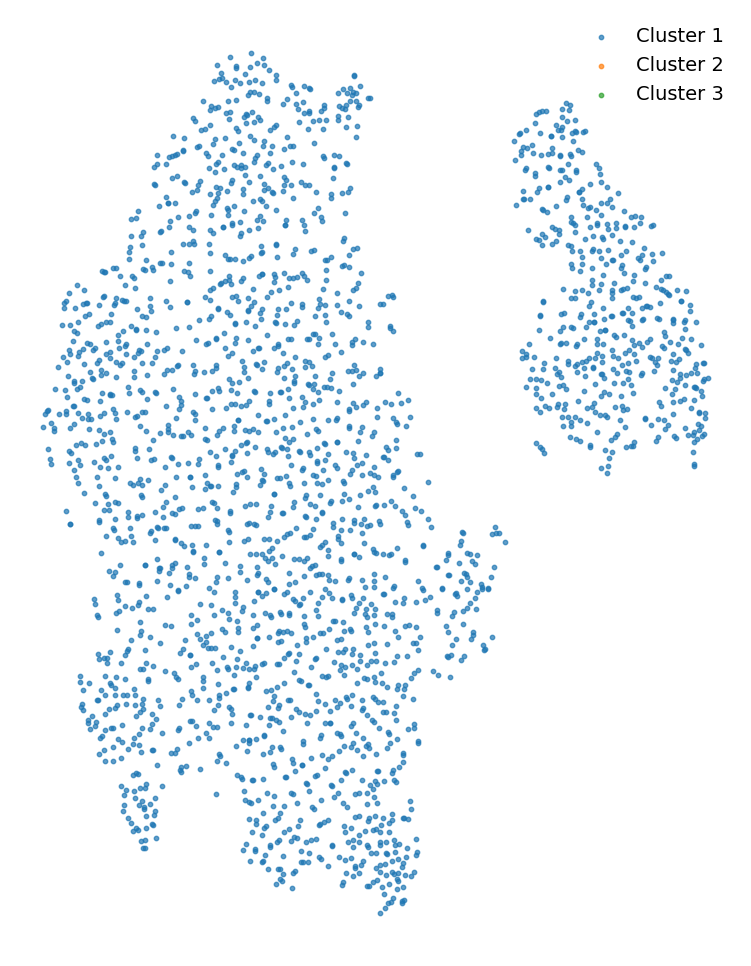

In [158]:
visualize_clusters(features, predictions, cluster_centers_list[-1])

In [159]:
time = cluster_centers_list.shape[0]
end_time =time
cluster_centers_distances=np.zeros((time, 2)) 

for batch in range(time):
    cluster_centers_distances[batch][:] = np.linalg.norm(cluster_centers_list[batch],axis=1)

# Plot the distances of the cluster centers over time
plt.figure(figsize=(10, 6), dpi=80)


for cluster_idx in range(cluster_number):
    #if cluster_idx in unique_values:
    plt.plot(range(end_time), cluster_centers_distances[:end_time, cluster_idx], label=f'Cluster {cluster_idx+1}')

#plt.plot(range(end_time),kldiv_loss_batches[: end_time], label = 'kldiv_loss')
plt.xlabel('Time ', fontsize=14)
plt.ylabel('Distance from Origin', fontsize=14)
#plt.xticks(fontsize=14) =[] # Set font size for x-ticks
plt.xticks([])
plt.yticks(fontsize=14)  # Set font size for y-ticks
#plt.title('Cluster Center Distances Over Time')
plt.legend( loc='center right', frameon=False, fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.show()

ValueError: could not broadcast input array from shape (3,) into shape (2,)

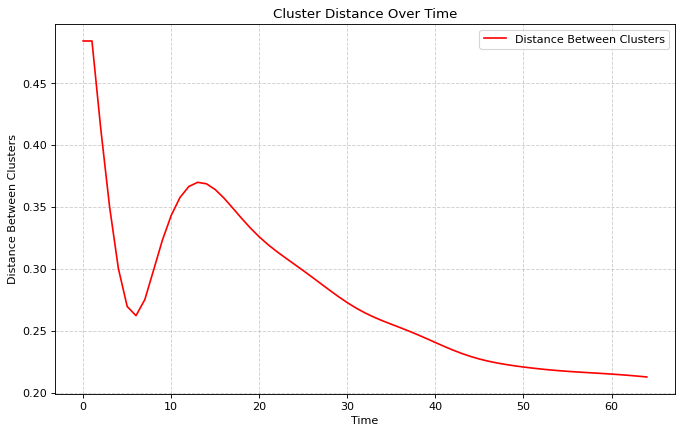

In [152]:
time = cluster_centers_list.shape[0]
cluster_distances = np.zeros(time)

# Compute the Euclidean distance between the two cluster centers at each timestep
for t in range(time):
    cluster_distances[t] = np.linalg.norm(cluster_centers_list[t, 0] - cluster_centers_list[t, 1])

# Plot the distance between the two clusters over time
plt.figure(figsize=(10, 6), dpi=80)
plt.plot(range(time), cluster_distances, label='Distance Between Clusters', color='r')

plt.xlabel('Time')
plt.ylabel('Distance Between Clusters')
plt.title('Cluster Distance Over Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()